# Práctica 1: Perceptrón multicapa.

Tu jefe pidió a RH que recolectara datos de desempeño de tus compañeros, los resultados se almacenaron en un csv. El punto critico de estos datos es la satisfacción del empleado, entonces ¿Podremos estimar la satisfacción de los empleados con los datos recabados?.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models


df = pd.read_csv('Extended_Employee_Performance_and_Productivity_Data.csv')
df.info()

I0000 00:00:1774292007.531746   10862 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774292008.312383   10862 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774292010.610369   10862 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Employee_ID                  100000 non-null  int64  
 1   Department                   100000 non-null  str    
 2   Gender                       100000 non-null  str    
 3   Age                          100000 non-null  int64  
 4   Job_Title                    100000 non-null  str    
 5   Hire_Date                    100000 non-null  str    
 6   Years_At_Company             100000 non-null  int64  
 7   Education_Level              100000 non-null  str    
 8   Performance_Score            100000 non-null  int64  
 9   Monthly_Salary               100000 non-null  float64
 10  Work_Hours_Per_Week          100000 non-null  int64  
 11  Projects_Handled             100000 non-null  int64  
 12  Overtime_Hours               100000 non-null  int64  
 13  Sick_Days  

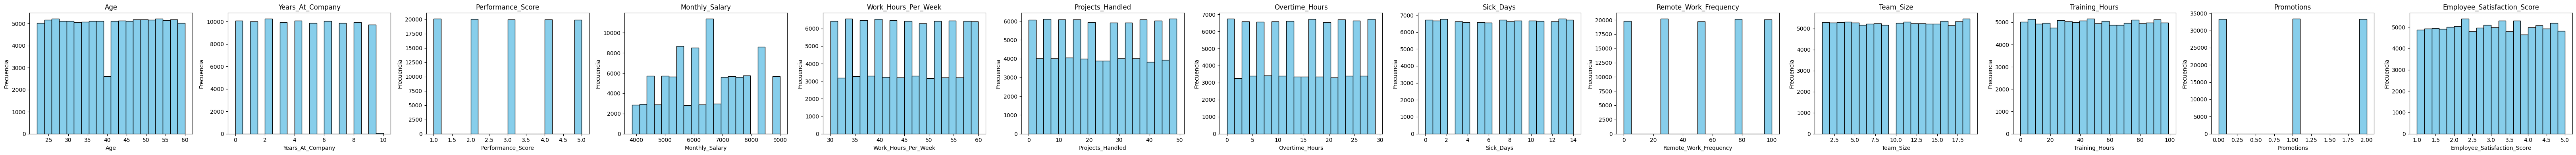

In [5]:
# Filtrar las columnas numéricas
numeric_columns = df.select_dtypes(include=['number']).drop('Employee_ID',axis=1)


# Si numeric_columns es un Index, conviértelo a lista
cols = list(numeric_columns)

fig, axes = plt.subplots(1, len(cols), figsize=(5 * len(cols), 4))

for i, col in enumerate(cols):
    axes[i].hist(df[col], bins=20, color='skyblue', edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

**Problemas**, tenemos distribuciones con picos, esos nos indica categorías. Por otro lado, tenemos variables con "valles" en su distribución (distribuciones multimodales) por lo que resultaría óptimo aplicar técnicas de feature engeneering. Por último tenemos distribuciones uniformes, por lo que cada una requeriría un procesamiento indivudual, hagamos la vista gorda e intentemos ajustar un MLP con estos datos, solo estandaricemos nuestros datos.

---

## Implementación de Red:

To**memos los datos numéricos como nuestra variable X, y la variable objetivo como ***'Employee_Satisfaction_Score'***.
- **Actividad 1**: Para todos los strings ``'@modif@'`` que aparescan en el siguiente bloque de código cámbialos para que el código funcione.

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf

# Supongamos que numeric_columns es tu DataFrame con las variables numéricas
# X = todas las columnas menos la de satisfacción
X = numeric_columns.drop('Employee_Satisfaction_Score', axis=1)

# y = la columna objetivo
y = numeric_columns['Employee_Satisfaction_Score']

# Convertimos la variable objetivo a categorías numéricas (0–4)
y = y.apply(lambda x: round(x) - 1)

# Escalamos las variables de entrada
scaler = StandardScaler()
X_standar = scaler.fit_transform(X)

# Dividimos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_standar, y, test_size=0.33, random_state=42)

# Convertimos la variable objetivo a one-hot encoding
y_onehot_train = tf.keras.utils.to_categorical(y_train, 5)
y_onehot_test = tf.keras.utils.to_categorical(y_test, 5)


- **Actividad 2:** Implementa 3 arquitecturas de MLP, cada una con su propio nombre, cambiando la estructura de dichas arquitecturas (capas, neuronas por capa, función de activación, etc). 

In [ ]:
# En las siguientes celdas, construye tu modelo con tensorflow.keras solo la arquitectura

In [8]:
#separamos las variables de entrada (x) y salida (y)
X = numeric_columns.drop('Employee_Satisfaction_Score', axis=1)
y = numeric_columns['Employee_Satisfaction_Score']

#transformamos la variable objetivo en categorías numéricas
y = y.apply(lambda x: round(x) - 1)

#Normalizamos la variables de entrada
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_standar = scaler.fit_transform(X)

#Dividimos en entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_standar, y, test_size=0.33, random_state=42)

#Convertimos la salida a "one-hot encoding"
import tensorflow as tf
y_onehot_train = tf.keras.utils.to_categorical(y_train, 5)
y_onehot_test = tf.keras.utils.to_categorical(y_test, 5)


In [9]:
#Ya que preparamos los datos (X_train y one-hot_train, etc), definimos 3 modelos diferentes, cambiamos: número de capas ocultas, número de neuronas por capa y funciones de activación.
#Entrenamos cada modelo, guardamos los resultados y comparamos el desempeño (accuracy, loss)

import tensorflow as tf
from tensorflow.keras import layers, models

# Arquitectura 1: simple
model1 = models.Sequential(name="MLP_simple")
model1.add(layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model1.add(layers.Dense(5, activation='softmax'))

# Arquitectura 2: más profunda
model2 = models.Sequential(name="MLP_profundo")
model2.add(layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model2.add(layers.Dense(32, activation='relu'))
model2.add(layers.Dense(5, activation='softmax'))

# Arquitectura 3: variamos activaciones
model3 = models.Sequential(name="MLP_variante")
model3.add(layers.Dense(128, activation='tanh', input_shape=(X_train.shape[1],)))
model3.add(layers.Dense(64, activation='relu'))
model3.add(layers.Dense(5, activation='softmax'))

# Compilación y entrenamiento
for model in [model1, model2, model3]:
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    print(f"\nEntrenando {model.name}...")
    history = model.fit(X_train, y_onehot_train,
                        epochs=20,
                        batch_size=32,
                        validation_data=(X_test, y_onehot_test))



Entrenando MLP_simple...
Epoch 1/20


/root/deeplearning/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1774292868.653817   10862 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


2094/2094 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2545 - loss: 1.5734 - val_accuracy: 0.2492 - val_loss: 1.5633
Epoch 2/20
2094/2094 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2581 - loss: 1.5588 - val_accuracy: 0.2544 - val_loss: 1.5607
Epoch 3/20
2094/2094 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2621 - loss: 1.5564 - val_accuracy: 0.2485 - val_loss: 1.5618
Epoch 4/20
2094/2094 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2609 - loss: 1.5559 - val_accuracy: 0.2511 - val_loss: 1.5605
Epoch 5/20
2094/2094 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2620 - loss: 1.5553 - val_accuracy: 0.2544 - val_loss: 1.5599
Epoch 6/20
2094/2094 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2631 - loss: 1.5550 - val_accuracy: 0.2535 - val_loss: 1.5603
Epoch 7/20
2094/2094 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2644 - loss: 1.5546 - val_accuracy: 0.2509 - val_loss: 1.5600
Epoch 8/20
2094/2094 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2650 - loss: 1.5545 - val_accurac

Epoch 1/20
2094/2094 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2635 - loss: 1.5533 - val_accuracy: 0.2509 - val_loss: 1.5592
Epoch 2/20
2094/2094 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2635 - loss: 1.5530 - val_accuracy: 0.2525 - val_loss: 1.5596
Epoch 3/20
2094/2094 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2621 - loss: 1.5529 - val_accuracy: 0.2528 - val_loss: 1.5585
Epoch 4/20
2094/2094 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2638 - loss: 1.5527 - val_accuracy: 0.2517 - val_loss: 1.5594
Epoch 5/20
2094/2094 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2627 - loss: 1.5524 - val_accuracy: 0.2489 - val_loss: 1.5603
Epoch 6/20
2094/2094 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2637 - loss: 1.5523 - val_accuracy: 0.2510 - val_loss: 1.5599
Epoch 7/20
2094/2094 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2657 - loss: 1.5520 - val_accuracy: 0.2525 - val_loss: 1.5598
Epoch 8/20
2094/2094 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2623 - loss: 1.5519 - 

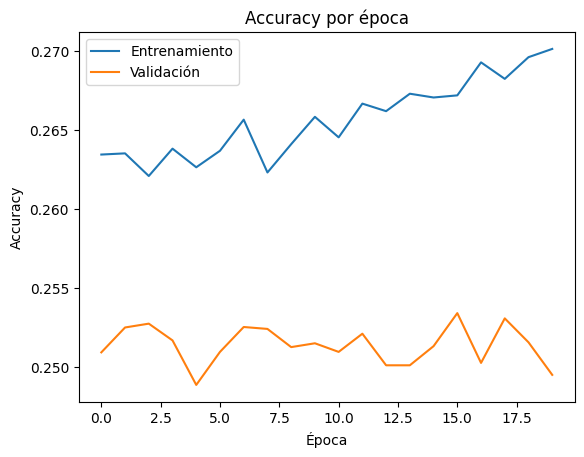

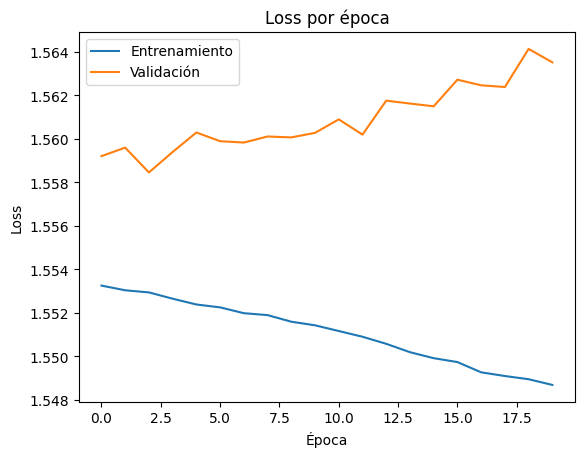

In [10]:
import matplotlib.pyplot as plt

# history es lo que devuelve model.fit()
history = model.fit(X_train, y_onehot_train,
                    epochs=20,
                    batch_size=32,
                    validation_data=(X_test, y_onehot_test))

# Gráfica de accuracy
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Accuracy por época')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Gráfica de loss
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Loss por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.show()


- **Actividad 3:** Compila y ajusta tus tres modelos con sus respectivos hiperparámetros.

In [ ]:
# En las siguientes celdas, compila y entrena el modelo

In [11]:
#1 compilamos cada modelo utilizando un optimizador (adam, sgd, rmsprop, definimos funciones de pérdida (para clasificación multiclase: categorical_crossentropy) y definimos las métricas (como accuracy)
model1.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

model2.compile(optimizer='sgd',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

model3.compile(optimizer='rmsprop',
               loss='categorical_crossentropy',
               metrics=['accuracy'])


In [12]:
#2 Entrenamos cada modelo llamando a fit() con nuestros datos de entrenamiento y validación, además de definir hiperparámetros como: epochs (es el número de iteraciones sobre el dataset), batch_size (es el tamaño del lote) y validation_data (para medir desempeño en datos de prueba)
history1 = model1.fit(X_train, y_onehot_train,
                      epochs=20,
                      batch_size=32,
                      validation_data=(X_test, y_onehot_test))

history2 = model2.fit(X_train, y_onehot_train,
                      epochs=30,
                      batch_size=64,
                      validation_data=(X_test, y_onehot_test))

history3 = model3.fit(X_train, y_onehot_train,
                      epochs=25,
                      batch_size=32,
                      validation_data=(X_test, y_onehot_test))


Epoch 1/20
2094/2094 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2685 - loss: 1.5533 - val_accuracy: 0.2547 - val_loss: 1.5597
Epoch 2/20
2094/2094 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2674 - loss: 1.5531 - val_accuracy: 0.2505 - val_loss: 1.5601
Epoch 3/20
2094/2094 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2681 - loss: 1.5532 - val_accuracy: 0.2524 - val_loss: 1.5599
Epoch 4/20
2094/2094 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2676 - loss: 1.5530 - val_accuracy: 0.2529 - val_loss: 1.5598
Epoch 5/20
2094/2094 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2674 - loss: 1.5531 - val_accuracy: 0.2534 - val_loss: 1.5600
Epoch 6/20
2094/2094 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2680 - loss: 1.5531 - val_accuracy: 0.2556 - val_loss: 1.5597
Epoch 7/20
2094/2094 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2687 - loss: 1.5529 - val_accuracy: 0.2553 - val_loss: 1.5599
Epoch 8/20
2094/2094 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2686 - loss: 1.5530 - 

In [13]:
#3Evaluamos el desempeño
print("Modelo 1:", model1.evaluate(X_test, y_onehot_test))
print("Modelo 2:", model2.evaluate(X_test, y_onehot_test))
print("Modelo 3:", model3.evaluate(X_test, y_onehot_test))


1032/1032 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2532 - loss: 1.5598
Modelo 1: [1.5597995519638062, 0.2531818151473999]
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2554 - loss: 1.5765
Modelo 2: [1.5765026807785034, 0.25542423129081726]
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2517 - loss: 1.5659
Modelo 3: [1.5659286975860596, 0.2516666650772095]


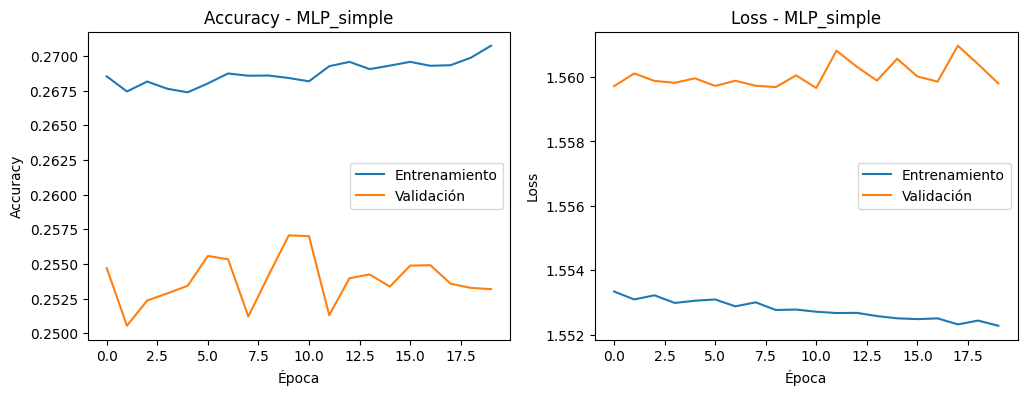

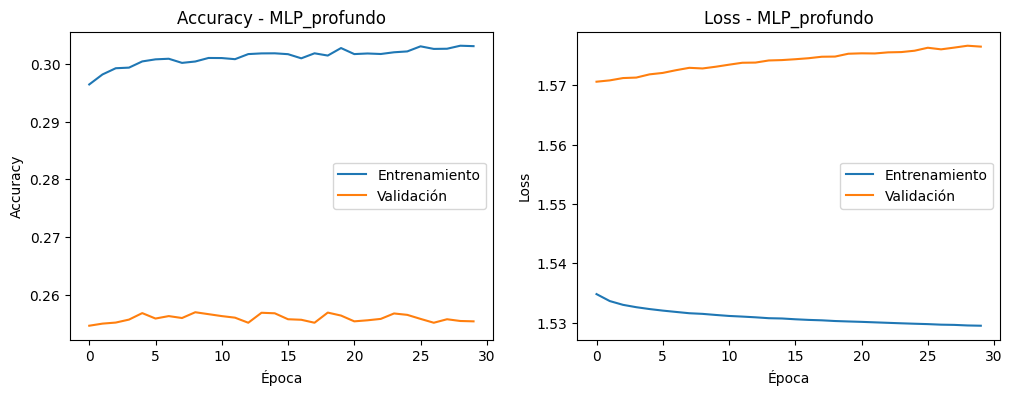

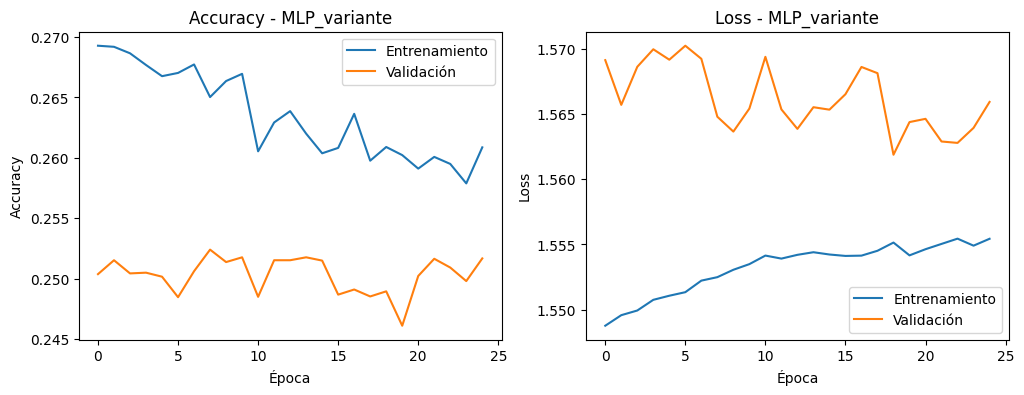

In [14]:
import matplotlib.pyplot as plt

def plot_history(history, model_name):
    # Accuracy
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Validación')
    plt.title(f'Accuracy - {model_name}')
    plt.xlabel('Época')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Entrenamiento')
    plt.plot(history.history['val_loss'], label='Validación')
    plt.title(f'Loss - {model_name}')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Después de entrenar cada modelo:
plot_history(history1, "MLP_simple")
plot_history(history2, "MLP_profundo")
plot_history(history3, "MLP_variante")


- **Actividad 4:** Sube tus cambios al repositorio, envía el link de tu repositorio a la actividad 2 de tu checkpoint 2 y contesta las preguntas de dicha actividad.